In [1]:
import pandas as pd
import numpy as np
from datetime import timedelta
import random

# Set seed for reproducibility
np.random.seed(42)
random.seed(42)

In [2]:
# 1. Facility Master (Czech Republic included, added Origin City)
# 1. Define the base facility information
facility_types = ['Plant', 'Port', 'Plant', 'Storage', 'Distribution Center']

# 2. Helper function to assign capacity ranges based on your rules
def get_capacity(fac_type):
    if fac_type == 'Port':
        return np.random.randint(4500, 5500) # Around 5k
    elif fac_type == 'Plant':
        return np.random.randint(10000, 20000)
    elif fac_type in ['Storage', 'Distribution Center']:
        return np.random.randint(40000, 50000)
    return 0

# 3. Cost mapping dictionary based on your uploaded table
cost_mapping = {
    'Port': {'Storage': 300000, 'Handling': 12.00, 'Overhead': 100000},
    'Plant': {'Storage': 800000, 'Handling': 6.50, 'Overhead': 250000},
    'Storage': {'Storage': 1200000, 'Handling': 4.50, 'Overhead': 150000},
    'Distribution Center': {'Storage': 1500000, 'Handling': 5.50, 'Overhead': 350000}
}

# 4. Generate the dataframe
facilities = pd.DataFrame({
    'FacilityID': ['F01', 'F02', 'F03', 'F04', 'F05'],
    'FacilityName': ['Bavaria Dairy Plant', 'Maasvlakte Port DC', 'Laval Dairy Plant', 'Cremona Storage Hub', 'Brno South Logistics'],
    'FacilityType': facility_types,
    'Address': ['Megglestr. 1', 'Maasvlakte Blvd', 'Z.I. des Touches', 'Via Eridano', 'Průmyslová 1'],
    'City': ['Wasserburg', 'Rotterdam', 'Laval', 'Cremona', 'Pohořelice'],
    'Country': ['Germany', 'Netherlands', 'France', 'Italy', 'Czech Republic'],
    'Latitude': [48.0610, 51.9540, 48.0650, 45.1230, 48.9750],   
    'Longitude': [12.2280, 4.0530, -0.7510, 10.0080, 16.5180],
    
    # Apply the capacity function and cost mappings via list comprehensions
    'CapacityInPallet': [get_capacity(ft) for ft in facility_types],
    'AnnualStorageCost': [cost_mapping[ft]['Storage'] for ft in facility_types],
    'HandlingCostPerPallet': [cost_mapping[ft]['Handling'] for ft in facility_types],
    'TotalOverheadCost': [cost_mapping[ft]['Overhead'] for ft in facility_types]
})

In [3]:
# 2. Customer Master (Now mapped to specific Cities)
eu_countries = ['Germany', 'France', 'Italy', 'Spain', 'Netherlands', 'Belgium', 'Czech Republic', 'Sweden']
country_weights = [0.28, 0.22, 0.18, 0.12, 0.08, 0.05, 0.04, 0.03] 

city_coords = {
    'Germany': {'Berlin': (52.52, 13.40), 'Munich': (48.13, 11.58), 'Hamburg': (53.55, 9.99), 'Frankfurt': (50.11, 8.68)},
    'France': {'Paris': (48.85, 2.35), 'Lyon': (45.76, 4.83), 'Marseille': (43.29, 5.36), 'Toulouse': (43.60, 1.44)},
    'Italy': {'Rome': (41.90, 12.49), 'Milan': (45.46, 9.19), 'Naples': (40.85, 14.26), 'Turin': (45.07, 7.68)},
    'Spain': {'Madrid': (40.41, -3.70), 'Barcelona': (41.38, 2.16), 'Valencia': (39.46, -0.37), 'Seville': (37.38, -5.98)},
    'Netherlands': {'Amsterdam': (52.36, 4.90), 'Rotterdam': (51.92, 4.47), 'The Hague': (52.07, 4.30), 'Utrecht': (52.09, 5.12)},
    'Belgium': {'Brussels': (50.85, 4.35), 'Antwerp': (51.21, 4.40), 'Ghent': (51.05, 3.71), 'Liege': (50.63, 5.57)},
    'Czech Republic': {'Prague': (50.07, 14.43), 'Brno': (49.19, 16.60), 'Ostrava': (49.82, 18.26), 'Plzen': (49.73, 13.37)},
    'Sweden': {'Stockholm': (59.32, 18.06), 'Gothenburg': (57.70, 11.97), 'Malmo': (55.60, 13.00), 'Uppsala': (59.85, 17.63)}
}

dairy_prefixes = ['Alpine', 'Nordic', 'Euro', 'Pure', 'Green', 'Valley', 'Golden']
dairy_suffixes = ['Dairy', 'Foods', 'Milk Co.', 'Nutrition', 'Brands']
channels = ['Retail', 'Foodservice', 'Wholesale', 'Manufacturing', 'Key Account']

customers = []
for i in range(1, 251): 
    account_name = f"{random.choice(dairy_prefixes)} {random.choice(dairy_suffixes)}"
    # Apply population weights here
    country = np.random.choice(eu_countries, p=country_weights)
    city = random.choice(list(city_coords[country].keys()))
    
    base_lat, base_lon = city_coords[country][city]
    
    customers.append({
        'ShipToID': f"ST{i:04d}",
        'ShipToParty': f"{account_name} - {city}",
        'Account': account_name,
        'Channel': np.random.choice(channels, p=[0.4, 0.25, 0.15, 0.1, 0.1]),
        # 'ABCClass': np.random.choice(['A', 'B', 'C'], p=[0.2, 0.3, 0.5]),
        'Address': f"{np.random.randint(1, 999)} Commerce St",
        'City': city,
        'ShipToCountry': country,
        'Continent': 'Europe',
        'Latitude': round(base_lat + np.random.uniform(-0.05, 0.05), 5),
        'Longitude': round(base_lon + np.random.uniform(-0.05, 0.05), 5)
    })
customer_master = pd.DataFrame(customers)

In [4]:
# 3. Product Master
# Category setup
category_distribution = (['Cheese'] * 35) + (['Butter'] * 30) + (['UHT'] * 25) + (['Powder'] * 10)
random.shuffle(category_distribution)

# 1. Define Price ranges per KG (Powder > Cheese > Butter > UHT)
price_per_kg_ranges = {
    'Powder': (10.0, 15.0),  # Premium priced
    'Cheese': (7.0, 10.0),   # Value-add
    'Butter': (4.5, 7.0),    # High raw material dependence
    'UHT':    (0.8, 1.5)     # Liquid, heavy, volume business
}

# 2. Define COGS % of Sales Price (Based on milk volume & production time)
cogs_margin_ranges = {
    'Powder': (0.70, 0.80),  # High energy cost for spray drying
    'Cheese': (0.65, 0.75),  # Best margin due to aging/value-add
    'Butter': (0.80, 0.85),  # High COGS due to taking 20L milk per KG
    'UHT':    (0.85, 0.90)   # Tightest margin, fast commodity
}

products = []
for i in range(1, 101):
    cat = category_distribution[i-1]
    kg_pallet = np.random.choice([500, 800, 1000])
    sales_unit = 'Carton' if cat in ['UHT', 'Butter', 'Cheese'] else 'Bag'
    kg_su = 10 if sales_unit == 'Carton' else 25
    
    # Calculate realistic Price
    base_price_per_kg = np.random.uniform(*price_per_kg_ranges[cat])
    price = base_price_per_kg * kg_su
    
    # Calculate realistic COGS based on category economics
    cogs_percentage = np.random.uniform(*cogs_margin_ranges[cat])
    cogs = price * cogs_percentage
    
    # Optional realism: Shelf life tuning based on category
    if cat == 'UHT': shelf_life = np.random.choice([180, 365])
    elif cat == 'Powder': shelf_life = np.random.choice([365, 730])
    elif cat == 'Cheese': shelf_life = np.random.choice([90, 180, 365])
    else: shelf_life = np.random.choice([90, 180]) # Butter
    
    products.append({
        'ProductID': f"P{i:03d}",
        'ProductName': f"Premium {cat} Variant {i}",
        'Category': cat,
        'KGPerPallet': kg_pallet,
        'SalesUnit': sales_unit,
        'KGPerSalesUnit': kg_su,
        'Price': round(price, 2),
        'COGS': round(cogs, 2),
        'ShelfLife': int(shelf_life)
    })

product_master = pd.DataFrame(products)

In [5]:
# Helper function to calculate distance between two coordinates in kilometers
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0 # Earth radius in km
    dLat = np.radians(lat2 - lat1)
    dLon = np.radians(lon2 - lon1)
    a = (np.sin(dLat / 2) ** 2 +
         np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dLon / 2) ** 2)
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

In [6]:
# 4. Transport Rate Card (By City, Distance-based formula)
# Base rate per pallet per KM
BASE_RATE_PER_KM = 0.1 
# Fixed additional rates reflecting labor/fuel indices in origin countries
additional_rates = {
    'Germany': 25.0,
    'Netherlands': 28.0,
    'France': 22.0,
    'Italy': 20.0,
    'Czech Republic': 12.0
}

rates = []
# Create a unique list of destination cities and their average coordinates from the Customer Master
unique_destinations = customer_master.groupby('City').agg({'Latitude':'mean', 'Longitude':'mean', 'ShipToCountry':'first'}).reset_index()

for _, fac in facilities.iterrows():
    for _, dest in unique_destinations.iterrows():
        # Calculate distance
        distance_km = haversine_distance(fac['Latitude'], fac['Longitude'], dest['Latitude'], dest['Longitude'])
        
        # Apply Formula: (Base * Distance) + Additional Country Rate
        origin_country = fac['Country']
        add_rate = additional_rates.get(origin_country, 15.0)
        cost_per_pallet = (BASE_RATE_PER_KM * distance_km) + add_rate
        
        rates.append({
            'OriginFacility': fac['FacilityName'],
            'OriginCity': fac['City'],
            'OriginCountry': origin_country,
            'DestinationCity': dest['City'],
            'DestinationCountry': dest['ShipToCountry'],
            'DistanceKM': round(distance_km, 2),
            'AdditionalRate': round(add_rate, 2),
            'CostPerPallet': round(cost_per_pallet, 2)
        })
transport_rates = pd.DataFrame(rates)

In [7]:
# 5. Sales Orders (Daily random generation for 2025)
num_orders = 200000

# 1. Get all start-of-month dates in the range (24 months)
months = pd.date_range(start="2024-01-01", end="2025-12-31", freq='MS')

# 2. Calculate exactly how many orders belong to each month
orders_per_month = num_orders // len(months)
remainder = num_orders % len(months)

# 3. Generate dates ensuring an even split across every single month
balanced_dates = []
for month_start in months:
    # Get all days within this specific month
    days_in_month = pd.date_range(start=month_start, end=month_start + pd.offsets.MonthEnd(0))
    # Assign the required number of orders to random days in this month
    balanced_dates.extend(np.random.choice(days_in_month, orders_per_month))

# Add any leftover orders (from division remainder) anywhere in the 2 years
if remainder > 0:
    all_days = pd.date_range(start="2024-01-01", end="2025-12-31")
    balanced_dates.extend(np.random.choice(all_days, remainder))

# Shuffle the dates so they aren't perfectly chronological in the dataframe
np.random.shuffle(balanced_dates)

# ==========================================
# The rest of your code remains the same
# ==========================================
taste_matrix = {
    'France':         [0.40, 0.45, 0.10, 0.05],
    'Italy':          [0.55, 0.10, 0.30, 0.05],
    'Germany':        [0.35, 0.30, 0.25, 0.10],
    'Netherlands':    [0.60, 0.15, 0.15, 0.10],
    'Spain':          [0.30, 0.10, 0.55, 0.05],
    'Belgium':        [0.35, 0.35, 0.20, 0.10],
    'Czech Republic': [0.35, 0.30, 0.25, 0.10],
    'Sweden':         [0.30, 0.25, 0.40, 0.05]
}
categories_list = ['Cheese', 'Butter', 'UHT', 'Powder']

# Pre-map categories to their available Product IDs for fast lookup
cat_to_prods = product_master.groupby('Category')['ProductID'].apply(list).to_dict()

# Base dataframe for orders (USING THE NEW BALANCED DATES)
sales_orders = pd.DataFrame({
    'OrderID': [f"SO{i:06d}" for i in range(1, num_orders + 1)],
    'FacilityID': np.random.choice(['F01', 'F02', 'F03', 'F04', 'F05'], num_orders),
    'ShipToID': np.random.choice(customer_master['ShipToID'], num_orders),
    'Date': balanced_dates,  # <--- Replaced np.random.choice here
    'SalesVolume': np.random.randint(10, 500, num_orders)
})

# Merge to get the destination country for each order
sales_orders = sales_orders.merge(customer_master[['ShipToID', 'ShipToCountry']], on='ShipToID', how='left')

# Function to apply cultural taste weights
def assign_product_by_culture(country):
    # 1. Pick a category based on the country's specific taste profile
    chosen_category = np.random.choice(categories_list, p=taste_matrix[country])
    # 2. Pick a random ProductID from that specific category
    return random.choice(cat_to_prods[chosen_category])

# Apply the logic row-by-row
sales_orders['ProductID'] = sales_orders['ShipToCountry'].apply(assign_product_by_culture)

# Clean up temporary column used for logic
sales_orders = sales_orders.drop(columns=['ShipToCountry'])

In [8]:
# 6. Inventory (Weekly snapshot)
# Merge with Product Master to get unit weights
sales_merged = sales_orders.merge(product_master[['ProductID', 'KGPerSalesUnit', 'KGPerPallet']], on='ProductID', how='left')

# Calculate exact pallets shipped per order
sales_merged['SalesVolumeKG'] = sales_merged['SalesVolume'] * sales_merged['KGPerSalesUnit']
sales_merged['SalesPallets'] = sales_merged['SalesVolumeKG'] / sales_merged['KGPerPallet']

# Ensure the Date column is datetime
sales_merged['Date'] = pd.to_datetime(sales_merged['Date'])

# 2. Aggregate Sales by Week, Facility, and Product
# freq='W' automatically groups daily sales into weekly buckets (ending on Sunday)
weekly_sales = sales_merged.groupby([
    pd.Grouper(key='Date', freq='W'), 
    'FacilityID', 
    'ProductID'
])['SalesPallets'].sum().reset_index()

weekly_sales.rename(columns={'Date': 'Week'}, inplace=True)

# 3. Generate the Inventory matching the Sales + Facility Capacity
weekly_dates = pd.date_range(start="2024-01-01", end="2025-12-31", freq='W')
capacity_dict = facilities.set_index('FacilityID')['CapacityInPallet'].to_dict()

inventory_records = []

for current_week in weekly_dates:
    # Filter sales that happened in this specific week
    week_sales = weekly_sales[weekly_sales['Week'] == current_week]
    
    for fac_id, capacity in capacity_dict.items():
        # Filter sales for this facility this week
        fac_week_sales = week_sales[week_sales['FacilityID'] == fac_id]
        
        # Determine target total pallets for this facility (60% to 105% capacity)
        target_utilization = np.random.uniform(0.60, 1.05)
        target_total_pallets = capacity * target_utilization
        
        base_inventory = {}
        total_required_pallets = 0
        
        # Step A: Secure inventory for all products that were sold this week
        if not fac_week_sales.empty:
            for _, row in fac_week_sales.iterrows():
                # Round up to ensure we have enough whole pallets to cover the sales
                required_pallets = np.ceil(row['SalesPallets'])
                base_inventory[row['ProductID']] = required_pallets
                total_required_pallets += required_pallets
        
        # Step B: Fill the remaining facility capacity with random inventory
        remaining_pallets = target_total_pallets - total_required_pallets
        
        if remaining_pallets > 0:
            sold_products = list(base_inventory.keys())
            other_products = list(set(product_master['ProductID']) - set(sold_products))
            
            # Pick additional random products so the warehouse has ~30-60 active SKUs
            num_additional = max(0, np.random.randint(30, 61) - len(sold_products))
            num_additional = min(num_additional, len(other_products))
            
            additional_products = np.random.choice(other_products, size=num_additional, replace=False).tolist() if num_additional > 0 else []
            all_active_products = sold_products + additional_products
            
            # Distribute the remaining pallets mathematically across these active products
            weights = np.random.dirichlet(np.ones(len(all_active_products)), size=1)[0]
            distributed_volumes = np.round(weights * remaining_pallets).astype(int)
            
            for prod, extra_vol in zip(all_active_products, distributed_volumes):
                base_inventory[prod] = base_inventory.get(prod, 0) + extra_vol

        # Append to the final inventory records
        for prod, vol in base_inventory.items():
            # Ensure no zeroes accidentally make it into the inventory table
            final_vol = max(int(vol), 1)
            
            inventory_records.append({
                'Date': current_week,
                'FacilityID': fac_id,
                'ProductID': prod,
                'VolumeInPallet': final_vol
            })

inventory = pd.DataFrame(inventory_records)

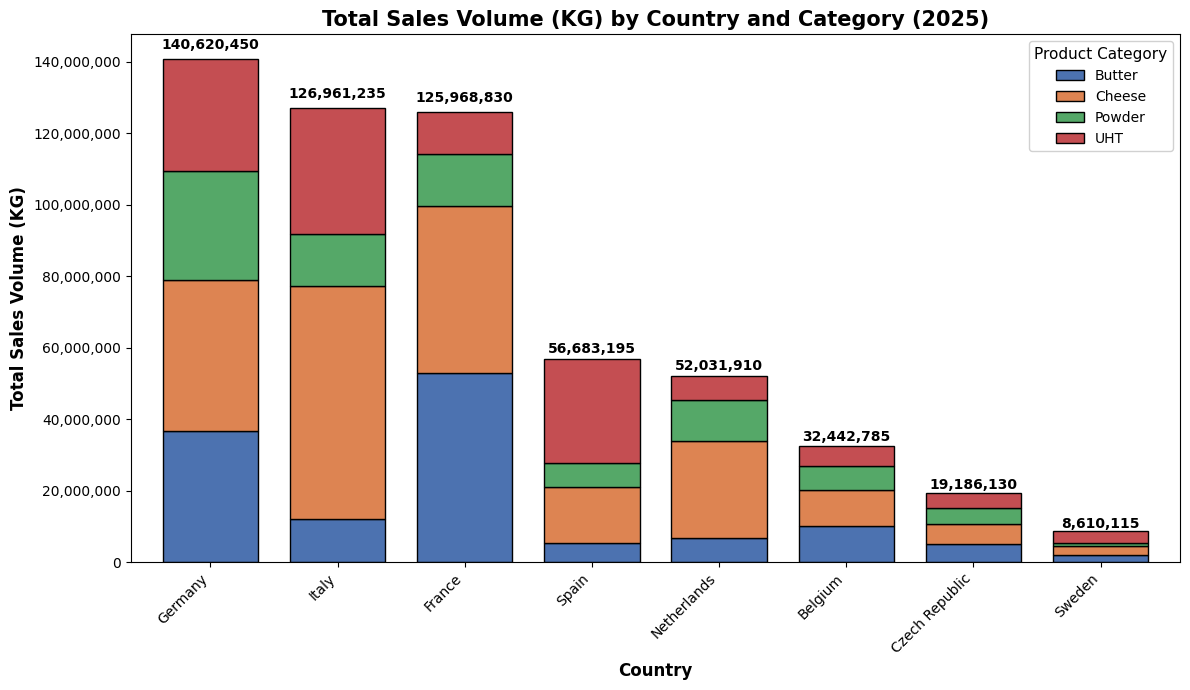

In [9]:
import matplotlib.pyplot as plt

# 1. Merge the data to get Country, Category, and KG conversion rate
# Assuming you have already loaded: sales_orders, customer_master, product_master
df = sales_orders.merge(customer_master[['ShipToID', 'ShipToCountry']], on='ShipToID', how='left')
df = df.merge(product_master[['ProductID', 'Category', 'KGPerSalesUnit']], on='ProductID', how='left')

# 2. Calculate volume in KG
df['SalesVolumeKG'] = df['SalesVolume'] * df['KGPerSalesUnit']

# 3. Group by Country and Category, then unstack to create category columns
grouped = df.groupby(['ShipToCountry', 'Category'])['SalesVolumeKG'].sum().unstack(fill_value=0)

# 4. Calculate a 'Total' to sort the bars descending, then drop it so it doesn't plot as a category
grouped['Total'] = grouped.sum(axis=1)
grouped = grouped.sort_values('Total', ascending=False).drop(columns='Total')

# 5. Create stacked bar chart
fig, ax = plt.subplots(figsize=(12, 7))

# Custom distinct colors for the dairy categories
colors = ['#4c72b0', '#dd8452', '#55a868', '#c44e52']
grouped.plot(kind='bar', stacked=True, ax=ax, color=colors[:len(grouped.columns)], edgecolor='black', width=0.75)

# Formatting
ax.set_title('Total Sales Volume (KG) by Country and Category (2025)', fontsize=15, fontweight='bold')
ax.set_xlabel('Country', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Sales Volume (KG)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')

# Format y-axis to show commas (e.g., 1,000,000 instead of 1000000)
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
ax.legend(title='Product Category', title_fontsize='11', fontsize='10', loc='upper right', framealpha=0.9)

# Add totals on top of each stacked bar
totals = grouped.sum(axis=1)
for i, total in enumerate(totals):
    ax.text(i, total + (total * 0.015), f"{int(total):,}", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('sales_volume_kg_stacked.png', dpi=150)
plt.show()

In [10]:
df = sales_orders.merge(product_master, on='ProductID', how='left')
df = df.merge(customer_master, on='ShipToID', how='left')
df = df.rename(columns={
'Address': 'Address_ShipTo',
'City': 'City_ShipTo',
'Continent': 'Continent_ShipTo',
'Latitude': 'Latitude_ShipTo',
'Longitude': 'Longitude_ShipTo'
})
df.head()

,OrderID,FacilityID,ShipToID,Date,SalesVolume,ProductID,ProductName,Category,KGPerPallet,SalesUnit,...,ShelfLife,ShipToParty,Account,Channel,Address_ShipTo,City_ShipTo,ShipToCountry,Continent_ShipTo,Latitude_ShipTo,Longitude_ShipTo
0,SO000001,F04,ST0011,2025-03-09,63,P018,Premium Cheese Variant 18,Cheese,800,Carton,...,180,Valley Nutrition - Naples,Valley Nutrition,Retail,703 Commerce St,Naples,Italy,Europe,40.88423,14.25498
1,SO000002,F04,ST0184,2025-11-20,118,P038,Premium Cheese Variant 38,Cheese,800,Carton,...,90,Golden Dairy - Liege,Golden Dairy,Foodservice,955 Commerce St,Liege,Belgium,Europe,50.62524,5.53409
2,SO000003,F05,ST0007,2024-09-06,205,P024,Premium Cheese Variant 24,Cheese,800,Carton,...,180,Nordic Brands - Rome,Nordic Brands,Retail,167 Commerce St,Rome,Italy,Europe,41.85133,12.53422
3,SO000004,F03,ST0145,2025-05-04,201,P065,Premium Cheese Variant 65,Cheese,500,Carton,...,365,Nordic Dairy - Milan,Nordic Dairy,Foodservice,748 Commerce St,Milan,Italy,Europe,45.42276,9.16838
4,SO000005,F01,ST0153,2024-01-30,95,P036,Premium Cheese Variant 36,Cheese,500,Carton,...,180,Euro Milk Co. - Frankfurt,Euro Milk Co.,Key Account,836 Commerce St,Frankfurt,Germany,Europe,50.10254,8.68076


In [11]:
df = df.merge(facilities, on='FacilityID', how='left')
df = df.rename(columns={
    'Address': 'Address_Facility',
    'City': 'City_Facility',
    'Country': 'Country_Facility',
    # 'Continent': 'Continent_ShipTo',
    'Latitude': 'Latitude_Facility',
    'Longitude': 'Longitude_Facility'
})
df.head()

,OrderID,FacilityID,ShipToID,Date,SalesVolume,ProductID,ProductName,Category,KGPerPallet,SalesUnit,...,FacilityType,Address_Facility,City_Facility,Country_Facility,Latitude_Facility,Longitude_Facility,CapacityInPallet,AnnualStorageCost,HandlingCostPerPallet,TotalOverheadCost
0,SO000001,F04,ST0011,2025-03-09,63,P018,Premium Cheese Variant 18,Cheese,800,Carton,...,Storage,Via Eridano,Cremona,Italy,45.123,10.008,45390,1200000,4.5,150000
1,SO000002,F04,ST0184,2025-11-20,118,P038,Premium Cheese Variant 38,Cheese,800,Carton,...,Storage,Via Eridano,Cremona,Italy,45.123,10.008,45390,1200000,4.5,150000
2,SO000003,F05,ST0007,2024-09-06,205,P024,Premium Cheese Variant 24,Cheese,800,Carton,...,Distribution Center,Průmyslová 1,Pohořelice,Czech Republic,48.975,16.518,45191,1500000,5.5,350000
3,SO000004,F03,ST0145,2025-05-04,201,P065,Premium Cheese Variant 65,Cheese,500,Carton,...,Plant,Z.I. des Touches,Laval,France,48.065,-0.751,10860,800000,6.5,250000
4,SO000005,F01,ST0153,2024-01-30,95,P036,Premium Cheese Variant 36,Cheese,500,Carton,...,Plant,Megglestr. 1,Wasserburg,Germany,48.061,12.228,17270,800000,6.5,250000


In [12]:
transport_rates.columns

Index(['OriginFacility', 'OriginCity', 'OriginCountry', 'DestinationCity',
       'DestinationCountry', 'DistanceKM', 'AdditionalRate', 'CostPerPallet'],
      dtype='object')

In [13]:
df = df.merge(transport_rates, left_on=['City_Facility', 'City_ShipTo'], right_on=['OriginCity', 'DestinationCity'], how='left')
df.head()

,OrderID,FacilityID,ShipToID,Date,SalesVolume,ProductID,ProductName,Category,KGPerPallet,SalesUnit,...,HandlingCostPerPallet,TotalOverheadCost,OriginFacility,OriginCity,OriginCountry,DestinationCity,DestinationCountry,DistanceKM,AdditionalRate,CostPerPallet
0,SO000001,F04,ST0011,2025-03-09,63,P018,Premium Cheese Variant 18,Cheese,800,Carton,...,4.5,150000,Cremona Storage Hub,Cremona,Italy,Naples,Italy,587.78,20.0,78.78
1,SO000002,F04,ST0184,2025-11-20,118,P038,Premium Cheese Variant 38,Cheese,800,Carton,...,4.5,150000,Cremona Storage Hub,Cremona,Italy,Liege,Belgium,696.46,20.0,89.65
2,SO000003,F05,ST0007,2024-09-06,205,P024,Premium Cheese Variant 24,Cheese,800,Carton,...,5.5,350000,Brno South Logistics,Pohořelice,Czech Republic,Rome,Italy,846.48,12.0,96.65
3,SO000004,F03,ST0145,2025-05-04,201,P065,Premium Cheese Variant 65,Cheese,500,Carton,...,6.5,250000,Laval Dairy Plant,Laval,France,Milan,Italy,810.51,22.0,103.05
4,SO000005,F01,ST0153,2024-01-30,95,P036,Premium Cheese Variant 36,Cheese,500,Carton,...,6.5,250000,Bavaria Dairy Plant,Wasserburg,Germany,Frankfurt,Germany,343.67,25.0,59.37


In [14]:
df['SalesVolumeKG'] = df['SalesVolume'] * df['KGPerSalesUnit']
df['QuantityInMT'] = df['SalesVolumeKG'] / 1000
df['RawPallets'] = df['SalesVolumeKG'] / df['KGPerPallet']
df['PalletsShipped'] = np.ceil(df['RawPallets'] * 2) / 2  # Round to nearest 0.5

# --- Logistics Costs ---
df['TotalTransportCost'] = df['PalletsShipped'] * df['CostPerPallet']
df['TotalHandlingCost'] = df['PalletsShipped'] * df['HandlingCostPerPallet']

# --- Fixed Cost Allocation & IOC ---
# Step A: Avg Inventory
avg_inv = inventory.groupby(['FacilityID', 'ProductID'])['VolumeInPallet'].mean().reset_index(name='AvgInventoryInPallet')
fac_total = avg_inv.groupby('FacilityID')['AvgInventoryInPallet'].sum().reset_index(name='FacTotalAvgInventory')

alloc_df = avg_inv.merge(fac_total, on='FacilityID')
alloc_df['InvAllocRatio'] = alloc_df['AvgInventoryInPallet'] / alloc_df['FacTotalAvgInventory']
alloc_df['InvAllocRatio'] = alloc_df['InvAllocRatio'].fillna(0)

# Step B: Allocate to Facility-Product Level
alloc_df = alloc_df.merge(facilities[['FacilityID', 'AnnualStorageCost', 'TotalOverheadCost']], on='FacilityID')
alloc_df['StorageCost_FacProd'] = alloc_df['AnnualStorageCost'] * 2 * alloc_df['InvAllocRatio']
alloc_df['OverheadCost_FacProd'] = alloc_df['TotalOverheadCost'] * 2 * alloc_df['InvAllocRatio']

alloc_df = alloc_df.merge(product_master[['ProductID', 'COGS', 'KGPerPallet', 'KGPerSalesUnit']], on='ProductID')
alloc_df['COGSPerPallet'] = alloc_df['COGS'] * (alloc_df['KGPerPallet'] / alloc_df['KGPerSalesUnit'])
alloc_df['IOC_FacProd'] = 0.10 * alloc_df['AvgInventoryInPallet'] * alloc_df['COGSPerPallet']

# Step C: Allocate to Sales Order Row Level
sales_totals = df.groupby(['FacilityID', 'ProductID'])['SalesVolumeKG'].sum().reset_index(name='TotalSalesVolumeKG_FacProd')
alloc_df = alloc_df.merge(sales_totals, on=['FacilityID', 'ProductID'], how='left')
df = df.merge(alloc_df[['FacilityID', 'ProductID', 'StorageCost_FacProd', 'OverheadCost_FacProd', 'IOC_FacProd', 'TotalSalesVolumeKG_FacProd']], 
              on=['FacilityID', 'ProductID'], how='left')

df.fillna({'StorageCost_FacProd': 0, 'OverheadCost_FacProd': 0, 'IOC_FacProd': 0, 'TotalSalesVolumeKG_FacProd': 1}, inplace=True)

df['RowAllocRatio'] = df['SalesVolumeKG'] / df['TotalSalesVolumeKG_FacProd']
df['RowAllocRatio'] = df['RowAllocRatio'].replace([np.inf, -np.inf, np.nan], 0)

df['StorageCostAllocated'] = df['StorageCost_FacProd'] * df['RowAllocRatio']
df['OverheadCostAllocated'] = df['OverheadCost_FacProd'] * df['RowAllocRatio']
df['TotalStorageCost'] = df['StorageCostAllocated'] + df['OverheadCostAllocated']
df['IOC'] = df['IOC_FacProd'] * df['RowAllocRatio']

# --- Financial Waterfall ---
df['TotalSalesValue'] = df['SalesVolume'] * df['Price']
df['TotalCOGS'] = df['SalesVolume'] * df['COGS']

df['TotalS&D'] = df['TotalTransportCost'] + df['TotalHandlingCost'] + df['TotalStorageCost']
df['SGA'] = np.random.uniform(0.02, 0.05) * df['TotalSalesValue']
df['GM'] = df['TotalSalesValue'] - df['TotalCOGS']
df['CBM'] = df['GM'] - df['TotalS&D']
df['CBMAI'] = df['CBM'] - df['IOC']
df['EBITAI'] = df['CBMAI'] - df['SGA']

In [15]:
df['FY'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.strftime('%m-%Y')
df.columns

Index(['OrderID', 'FacilityID', 'ShipToID', 'Date', 'SalesVolume', 'ProductID',
       'ProductName', 'Category', 'KGPerPallet', 'SalesUnit', 'KGPerSalesUnit',
       'Price', 'COGS', 'ShelfLife', 'ShipToParty', 'Account', 'Channel',
       'Address_ShipTo', 'City_ShipTo', 'ShipToCountry', 'Continent_ShipTo',
       'Latitude_ShipTo', 'Longitude_ShipTo', 'FacilityName', 'FacilityType',
       'Address_Facility', 'City_Facility', 'Country_Facility',
       'Latitude_Facility', 'Longitude_Facility', 'CapacityInPallet',
       'AnnualStorageCost', 'HandlingCostPerPallet', 'TotalOverheadCost',
       'OriginFacility', 'OriginCity', 'OriginCountry', 'DestinationCity',
       'DestinationCountry', 'DistanceKM', 'AdditionalRate', 'CostPerPallet',
       'SalesVolumeKG', 'QuantityInMT', 'RawPallets', 'PalletsShipped',
       'TotalTransportCost', 'TotalHandlingCost', 'StorageCost_FacProd',
       'OverheadCost_FacProd', 'IOC_FacProd', 'TotalSalesVolumeKG_FacProd',
       'RowAllocRatio', 'Stor

In [16]:
final_cols = ['OrderID', 'Date', 'FY', 'Month','FacilityID', 'FacilityType', 'OriginCity', 'Country_Facility', 'ShipToID', 'ShipToParty','Account', 'DestinationCity', 'ShipToCountry', 
              'ProductID', 'ProductName','Category', 'QuantityInMT', 'PalletsShipped', 'TotalSalesValue', 'TotalCOGS', 
              'TotalStorageCost', 'TotalHandlingCost', 'TotalTransportCost', 'IOC', 'TotalS&D', 'GM', 'CBM', 'CBMAI', 'SGA', 'EBITAI']

final_df = df[final_cols]

In [17]:
# 1. Define the grouping keys
group_cols = ['FacilityID', 'ShipToID', 'ProductID', 'Month']

# 2. Define the columns to drop (we won't include them in the aggregation)
drop_cols = ['OrderID', 'Date']

# 3. Explicitly list the numerical columns that should be SUMMED
sum_cols = [
    'SalesVolume', 'SalesVolumeKG', 'QuantityInMT',
    'TotalTransportCost', 'TotalHandlingCost', 'StorageCostAllocated', 
    'OverheadCostAllocated', 'TotalStorageCost', 'IOC', 'TotalSalesValue', 
    'TotalCOGS', 'TotalS&D', 'SGA', 'GM', 'CBM', 'CBMAI', 'EBITAI'
]

# 4. Dynamically build the aggregation dictionary
agg_dict = {}
for col in final_df.columns:
    if col in group_cols or col in drop_cols:
        continue # Skip grouping keys and dropped columns
    elif col in sum_cols:
        agg_dict[col] = 'sum'
    else:
        # All other dimensional columns (Names, Categories, Prices, Lat/Long, etc.)
        # will just take the 'first' occurrence.
        agg_dict[col] = 'first'

# 5. Perform the GroupBy
df_monthly = final_df.groupby(group_cols).agg(agg_dict).reset_index()

In [18]:
df_monthly.head()

,FacilityID,ShipToID,ProductID,Month,FY,FacilityType,OriginCity,Country_Facility,ShipToParty,Account,...,TotalStorageCost,TotalHandlingCost,TotalTransportCost,IOC,TotalS&D,GM,CBM,CBMAI,SGA,EBITAI
0,F01,ST0001,P001,08-2024,2024,Plant,Wasserburg,Germany,Valley Dairy - Rome,Valley Dairy,...,31.415663,26.00,374.200,7.875088,431.615663,186.43,-245.185663,-253.060750,64.542415,-317.603165
1,F01,ST0001,P001,09-2025,2025,Plant,Wasserburg,Germany,Valley Dairy - Rome,Valley Dairy,...,36.101977,29.25,420.975,9.049824,486.326977,214.24,-272.086977,-281.136801,74.170289,-355.307091
2,F01,ST0001,P002,05-2025,2025,Plant,Wasserburg,Germany,Valley Dairy - Rome,Valley Dairy,...,61.271729,48.75,701.625,152.415623,811.646729,8525.79,7714.143271,7561.727648,1453.174054,6108.553594
3,F01,ST0001,P002,11-2024,2024,Plant,Wasserburg,Germany,Valley Dairy - Rome,Valley Dairy,...,42.244326,32.50,467.750,105.084275,542.494326,5878.18,5335.685674,5230.601398,1001.903479,4228.697920
4,F01,ST0001,P003,01-2025,2025,Plant,Wasserburg,Germany,Valley Dairy - Rome,Valley Dairy,...,77.128491,52.00,748.400,158.349206,877.528491,9623.60,8746.071509,8587.722303,1414.920379,7172.801925


In [19]:
df_monthly.to_csv('final_profit_and_loss_transactions.csv', index=False)